In [2]:
import pandas as pd
import numpy as np

In [3]:
df = pd.read_csv("powerplant_data.csv")
df.head()

,AT,V,AP,RH,PE
0,8.34,40.77,1010.84,90.01,480.48
1,23.64,58.49,1011.40,74.20,445.75
2,29.74,56.90,1007.15,41.91,438.76
3,19.07,49.69,1007.22,76.79,453.09
4,11.80,40.66,1017.13,97.20,464.43


In [4]:
X = df.drop("PE", axis=1)
y = df["PE"]

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [6]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [7]:
df.shape

(9568, 5)

In [8]:
y_train

5487    442.75
3522    432.52
6916    428.80
7544    426.07
7600    436.58
         ...  
5734    436.44
5191    441.20
5390    464.26
860     440.45
7270    484.44
Name: PE, Length: 7654, dtype: float64

In [9]:
import torch
import torch.nn as nn

X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)

X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1)

In [10]:
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

In [11]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32)

In [12]:
print(len(train_loader))

240


In [13]:
# Define our ANN Model

class ANN(nn.Module):
    def __init__(self):
        super(ANN, self).__init__()

        self.model = nn.Sequential(
            # 1st hidden layer
            nn.Linear(X_train.shape[1], 6),
            nn.ReLU(),
    
            # 2nd hidden layer
            nn.Linear(6, 6),
            nn.ReLU(),
    
            # output layer
            nn.Linear(6, 1),
        )

    def forward(self, x):
        return self.model(x)

In [14]:
import torch.optim as optim

model = ANN()

# loss, optimizer
crietrion = nn.MSELoss()
optimizer = optim.Adam(model.parameters())

In [15]:
train_losses = []
val_losses = []
best_val_loss = float("inf")


epochs = 100

for epoch in range(epochs):
    model.train()
    running_loss = 0.0 # tot training loss for 1 epoch
    
    for xb, yb in train_loader:
        # xb = features of 1 batch
        # yb = labels of 1 batch
        optimizer.zero_grad()
        
        outputs = model(xb) # forward prop....predicted outputs for this batch
        loss = crietrion(outputs, yb) # compute loss
        loss.backward() # back prop.. compute gradients
        optimizer.step() # params update
        
        running_loss += loss.item() # loss is a tensor => py float

    epoch_train_loss = running_loss / len(train_loader)
    train_losses.append(epoch_train_loss)


    # Validation
    model.eval()
    running_val_loss = 0.0

    with torch.no_grad(): # no gradients compute
        for xb, yb in test_loader:
            outputs = model(xb)
            loss = crietrion(outputs, yb)
            running_val_loss += loss

    epoch_val_loss = running_val_loss / len(test_loader)
    val_losses.append(epoch_val_loss)

    print(f"epoch {epoch+1}/{epochs} ==> train loss = {epoch_train_loss} & val loss = {epoch_val_loss}")

    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        torch.save(model.state_dict(), "best_model.pt")

epoch 1/100 ==> train loss = 204466.991796875 & val loss = 200046.3125
epoch 2/100 ==> train loss = 186741.36796875 & val loss = 166794.8125
epoch 3/100 ==> train loss = 136767.2962890625 & val loss = 104156.703125
epoch 4/100 ==> train loss = 74945.05074869792 & val loss = 51017.33203125
epoch 5/100 ==> train loss = 37590.607259114586 & val loss = 28384.88671875
epoch 6/100 ==> train loss = 23440.731791178387 & val loss = 19700.72265625
epoch 7/100 ==> train loss = 17270.00861816406 & val loss = 14871.3720703125
epoch 8/100 ==> train loss = 13001.14536743164 & val loss = 10847.328125
epoch 9/100 ==> train loss = 9177.325901285807 & val loss = 7291.806640625
epoch 10/100 ==> train loss = 5971.709916178385 & val loss = 4604.1318359375
epoch 11/100 ==> train loss = 3715.1014455159507 & val loss = 2867.9638671875
epoch 12/100 ==> train loss = 2312.025505065918 & val loss = 1817.8226318359375
epoch 13/100 ==> train loss = 1473.3334823608398 & val loss = 1201.7452392578125
epoch 14/100 ==> 

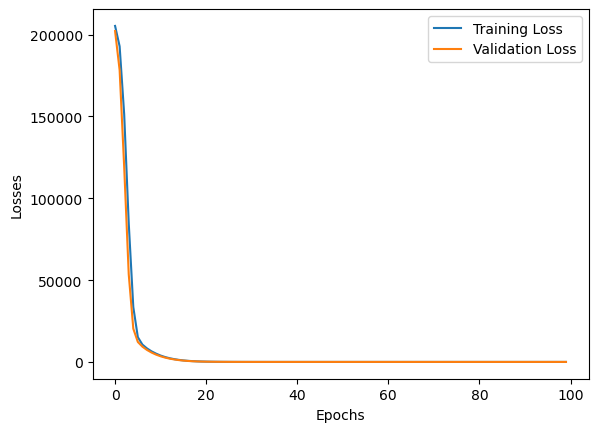

In [50]:
import matplotlib.pyplot as plt

loss_df = pd.DataFrame({
    "Training Loss": train_losses,
    "Validation Loss": val_losses
})

plt.plot(loss_df["Training Loss"], label = "Training Loss")
plt.plot(loss_df["Validation Loss"], label = "Validation Loss")

plt.xlabel("Epochs")
plt.ylabel("Losses")

plt.legend()

In [16]:
model.load_state_dict(torch.load("best_model.pt"))

<All keys matched successfully>

## Evaluation


In [21]:
model.eval()
with torch.no_grad():
    train_preds = model(X_train_tensor)
    test_preds = model(X_test_tensor)


    train_mese_loss = crietrion(train_preds, y_train_tensor)
    test_mse_loss = crietrion(test_preds, y_test_tensor)


print("Training MSE :", train_mese_loss.item())
print("Testing MSE :", test_mse_loss.item())

    



Training MSE : 21.13230323791504
Testing MSE : 19.57121467590332


In [22]:
from sklearn.metrics import r2_score

print("r2_score: ", r2_score(y_test, test_preds))

r2_score:  0.931603660867765


In [24]:
predicted_df = pd.DataFrame(test_preds.numpy(), columns=["Predicted Values"])
actual_df = pd.DataFrame(y_test.values, columns=["Actual Values"])


pd.concat([predicted_df, actual_df], axis=1)

,Predicted Values,Actual Values
0,435.712311,433.27
1,437.361664,438.16
2,461.310913,458.42
3,476.029022,480.82
4,435.974640,441.41
...,...,...
1909,451.346832,456.70
1910,432.112610,438.04
1911,467.605530,467.80
1912,431.617340,437.14
